# Topic 1: ZüriWieNeu Project: Spatial and Temporal Analysis of Citizen Reports in Zurich (2013-2026)

## Introduction
This project analyzes citizen reports from the "ZüriWieNeu" platform to identify spatial and temporal patterns of issues across Zurich neighborhoods.

The main research question is: *What spatial and temporal patterns characterize citizen reports in Zurich between 2013 and 2026?*

Sub-Questions:
1. Which neighborhoods reported the highest number of issues from 2013 to 2026?
2. Which issue categories were most frequent during this period and where?
3. How has reporting activity evolved over the years?
4. Are there seasonal trends in reporting activity between 2013 and 2026?

In [19]:
# Import required libraries
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

## Loading and Preparing the ZüriWieNeu Data

The ZüriWieNeu dataset was loaded as a CSV file using pandas. 
Coordinates were converted into geometries with GeoPandas to enable spatial operations. 
Datetime attributes were converted from string format to datetime format to enable temporal analysis.
Separate columns for year and month were created for temporal aggregation and seasonal analysis.

In [20]:
# Load ZüriWieNeu citizen report data
data_zwn = pd.read_csv("../data/raw/stzh.zwn_meldungen_p.csv")

#Renaming the columns for better understanding
data_zwn = data_zwn.rename(columns={
    "e":"x",
    "n": "y"
})

# Convert tabular report data into a spatial GeoDataFrame
zwn_gdf = gpd.GeoDataFrame (
    data_zwn, 
    geometry=gpd.points_from_xy(data_zwn["x"], data_zwn["y"]),
    crs="EPSG:2056"
)

# Convert all timestamps to datetime formats to enable temporal aggregation 
zwn_gdf["requested_datetime"] = pd.to_datetime(zwn_gdf["requested_datetime"])
zwn_gdf["agency_sent_datetime"] = pd.to_datetime(zwn_gdf["agency_sent_datetime"])
zwn_gdf["updated_datetime"] = pd.to_datetime(zwn_gdf["updated_datetime"])

# Extract requested year and month to analyze long-term trends and seasonal reporting patterns
zwn_gdf["year_requested"] = zwn_gdf["requested_datetime"].dt.year
zwn_gdf["month_requested"] = zwn_gdf["requested_datetime"].dt.month

# Match numeric month values to month names for visualization
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

# Store month names as ordered categorical values to preserve chronological order in the plots
zwn_gdf["month_name_requested"] = zwn_gdf["month_requested"].map(month_names)
month_order = [
    "January", "February", "March","April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
zwn_gdf["month_name_requested"] = pd.Categorical(
    zwn_gdf["month_name_requested"],
    categories=month_order,
    ordered=True
)


# Removing attributes that are not required for the spatial and temporal analyses
zwn_gdf = zwn_gdf.drop(columns=[
    "agency_sent_datetime", "updated_datetime", "status", "detail", "media_url", 
    "interface_used", "service_notice", "description", "url", "title", "userid",
    "x", "y"
])


## Loading and Preparing the Quartiere Data

The Quartiere dataset, representing the neighborhoods of Zurich, consists of two layers: geometries and attributes. The geometry and attribute layers were merged to combine spatial boundaries with neighborhood metadata.
The active geometry column was kept and the dataset was reprojected to match the CRS of the citizen report data.
Neighborhood areas were calculated to normalize report counts and enable density-based spatial comparisons. 

In [21]:
# Load Quartiere data of geometry and attribute infos separately
quartiere_geom = gpd.read_file("../data/raw/stzh.adm_statistische_quartiere_map.json")
quartiere_attr = gpd.read_file("../data/raw/stzh.adm_statistische_quartiere_b_p.json")

# Combine spatial boundaries with metadata using a shaerd object ID
quartiere = quartiere_geom.merge(quartiere_attr, on="objectid")

# Keep active geometry column and remove duplicate or unnecessary attributes
quartiere = quartiere.rename(columns={"geometry_x": "geometry"})
quartiere = quartiere.set_geometry("geometry")
quartiere = quartiere.drop(columns=["geometry_y", "objid", "ori", "hali", "vali"])

# Reproject neighborhoods to match the CRS of the citizen report dataset
quartiere = quartiere.to_crs(epsg=2056)

# Calculate neighborhood area to normalize report counts and compare fairly
quartiere["area_m2"] = quartiere.geometry.area
quartiere["area_km2"] = quartiere["area_m2"] / 1000000


## Joining Citizen Reports with Neighborhoods

A point-in-polygon spatial join was performed to assign each citizen report to its corresponding neighborhood polygon. This enables neighborhood level spatial analysis of reporting activity.

In [22]:
# Spatial Join: Link each citizen report to its neighborhood
zwn_quartiere_joined = gpd.sjoin(zwn_gdf, quartiere, predicate="within")

# Removing unnecessary columns created during spatial join
zwn_quartiere_joined = zwn_quartiere_joined.drop(columns=[
    "index_right", "objectid_left", "objectid_right"
])



## Research Question 1: Neighborhoods with the Highest Number of Reports from 2013 - 2026

Reports were accumulated by neighborhood to identify areas with the highest reporting activity between 2013 and 2026. 
The top 10 neighborhoods with the most reports over the years are identified. 

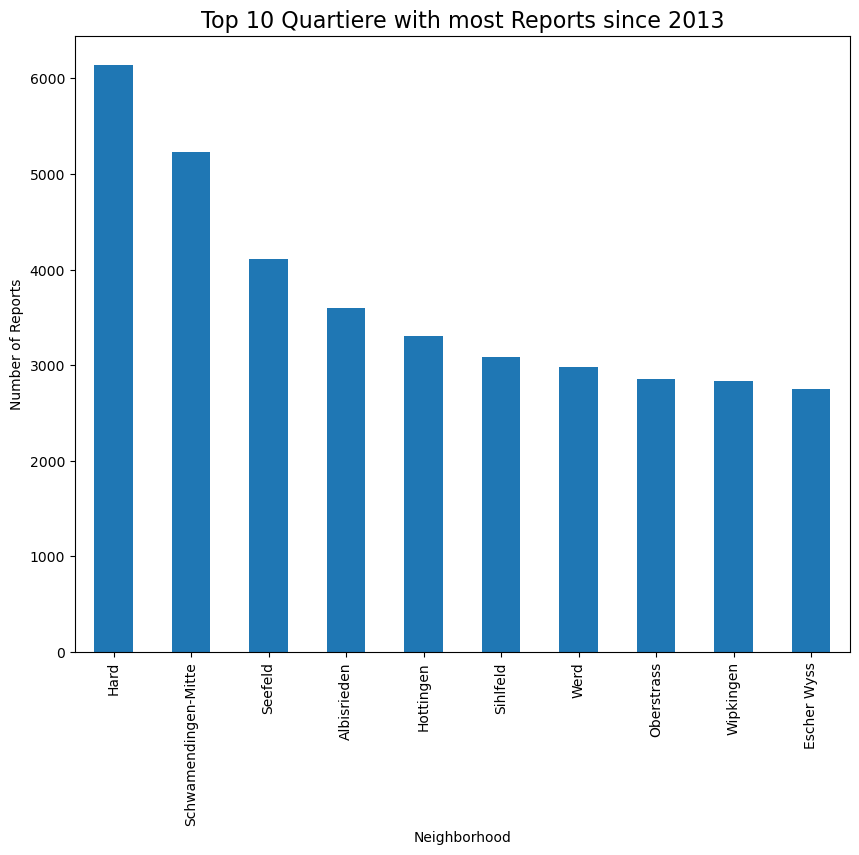

In [23]:
# Count reports per neighborhood to measure overall reporting activity
report_counts = (
    zwn_quartiere_joined.groupby("name")
    .size()
    .reset_index(name="report_count")
)

top10_quartier_reports = (
    report_counts
    .sort_values(by="report_count", ascending=False)
    .head(10)
)

# Visualize the top 10 neighborhoods with the largest number of reports as a bar chart
ax = top10_quartier_reports.plot(
    kind="bar", 
    x = "name", 
    y = "report_count", 
    figsize = (10,8), 
    legend=False
)

ax.set_xlabel("Neighborhood")
ax.set_ylabel("Number of Reports")
ax.set_title ("Top 10 Quartiere with most Reports since 2013", fontsize=16)


plt.savefig("../outputs/top10_neighborhoods_bar.png", dpi=300, bbox_inches="tight")

plt.show()

### Report Density per km2

To improve comparability between neighborhoods of different size, report counts were normalized by neighborhood area (reports per km2). 

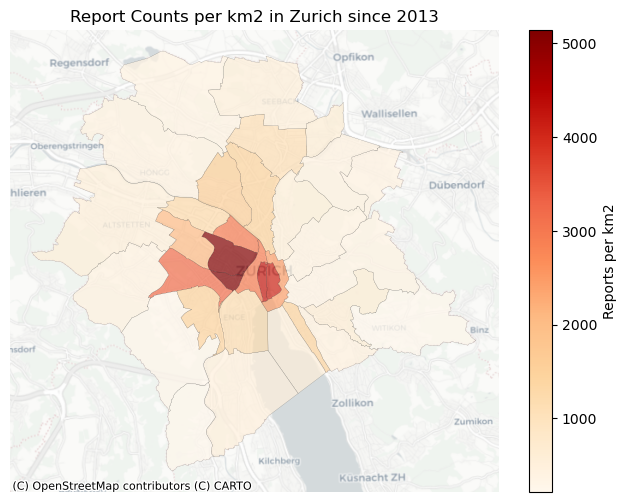

In [24]:
# Join neighborhood geometries with aggregated report counts for spatial visualization 
quartiere_reports = quartiere.merge (report_counts, on="name", how="left")

#Neighborhoods without reports are assigned zero counts
quartiere_reports["report_count"] = quartiere_reports["report_count"].fillna(0)

# Normalize report counts by neighborhood area for fair comparability
quartiere_reports["reports_per_km2"] = (
    quartiere_reports["report_count"] /quartiere_reports["area_km2"]
)

# Creating Legend options for choropleth visualization 
legend_options = {
     "label": "Reports per km2",
     "orientation": "vertical",
     "pad": 0.05
}

# Visualize spatial differences in reporting density across Zurich neighborhoods as a choropleth map
ax = quartiere_reports.plot(
    column="reports_per_km2",
    cmap="OrRd",
    alpha=0.7,
    figsize =(8,6), 
    legend=True, 
    edgecolor="black",
    linewidth=0.1,
    legend_kwds=legend_options
)

ctx.add_basemap(ax, crs=quartiere_reports.crs, source=ctx.providers.CartoDB.Positron)

ax.set_title("Report Counts per km2 in Zurich since 2013")
ax.axis("off")


plt.savefig("../outputs/report_counts_Zurich_choropleth.png", dpi=300, bbox_inches="tight")


plt.show()

## Research Question 2: Which issue categories were most frequent and where

The three most frequently reported service categories were selected for separate choropleth maps to examine their spatial distribution across Zurich. Report counts are normalized by area for comparability. 

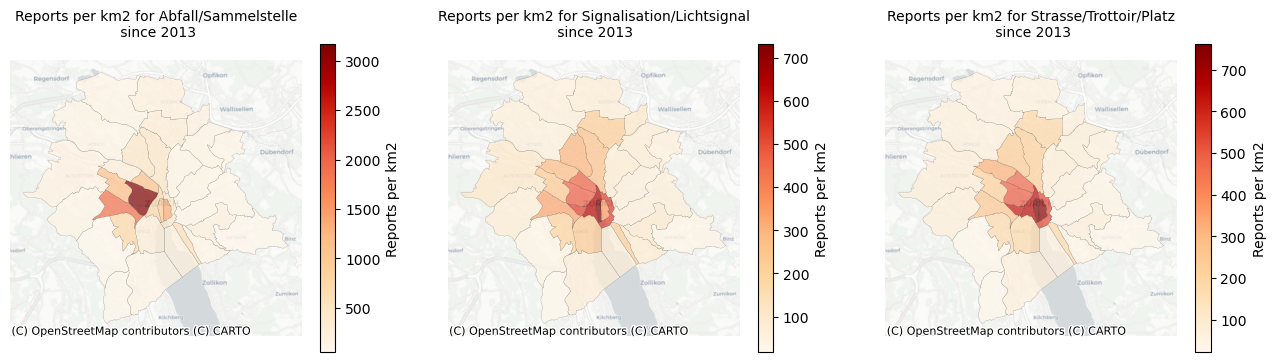

In [25]:
# Identify the top three frequently reported issue categories across the entire dataset 
top3_issues = (
    zwn_quartiere_joined["service_name"]
    .value_counts()
    .head(3)
    .index
)

# Preparing subplot with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# Loop through top 3 service codes to create individual choropleth maps for each issue category
for i, service_name in enumerate(top3_issues):
    service_data = zwn_quartiere_joined[zwn_quartiere_joined["service_name"] == service_name]
   
    service_counts = service_data.groupby("name").size().reset_index(name="service_counts")
    
    # Join category specific counts with the neighborhood geometries
    quartiere_service = quartiere.merge(service_counts, on="name", how="left")

    #Neighborhoods without reports for this category are treated as zero occurences
    quartiere_service["service_counts"] = quartiere_service["service_counts"].fillna(0)
    
    # Normalize category reports by area for spatial comparability
    quartiere_service ["service_per_km2"] = quartiere_service["service_counts"] / quartiere_service["area_km2"]
    
    # Creating Legend Options settings for consistency across all maps
    legend_options = {
        "label": "Reports per km2",
        "orientation": "vertical",
        "pad": 0.05
    }
    # Visualize the spatial concentration of the selected issue category
    quartiere_service.plot(
        column="service_per_km2", 
        cmap="OrRd",
        alpha= 0.7, 
        ax=axes[i], 
        edgecolor="black",
        linewidth=0.1, 
        legend=True,
        legend_kwds=legend_options
    )

    ctx.add_basemap(axes[i], crs=quartiere_service.crs, source=ctx.providers.CartoDB.Positron)
    
    axes[i].set_title(f"Reports per km2 for {service_name}\n since 2013", fontsize=10)
    axes[i].axis("off")


plt.savefig("../outputs/report_counts_neighborhoods_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()


## Research Question 3: Temporal Evolution of Reports including COVID-19 Impact

Reports are grouped by year to analyze temporal trends.
A monthly breakdown for 2019 and 2020 was included to examine potential changes in reporting behavior during the COVID-19 pandemic. 

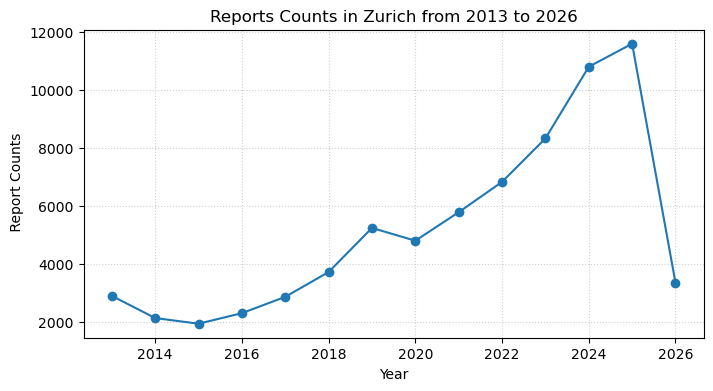

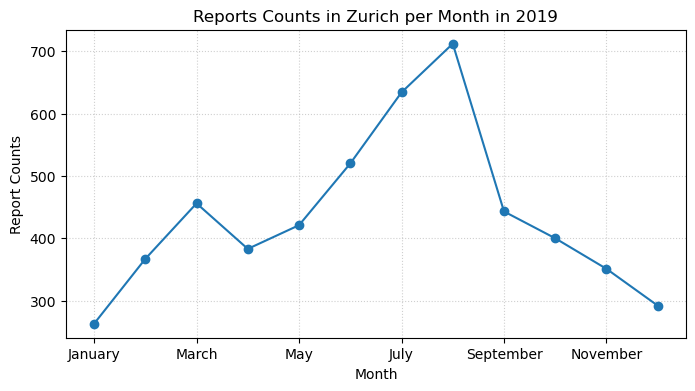

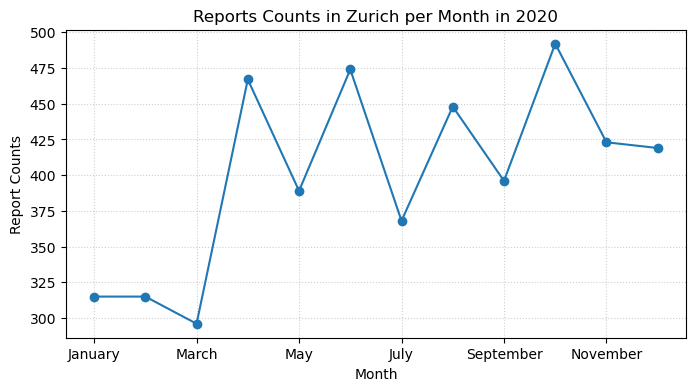

In [26]:
# Aggregate yearly report counts to examine long-term reporting patterns
reports_over_year = (
    zwn_quartiere_joined.groupby("year_requested").size()
)

# Visualize temporal changes in reporting activity across the study period
ax = reports_over_year.plot(
    kind="line", 
    figsize=(8,4), 
    title= "Reports Counts in Zurich from 2013 to 2026", 
    x="year_requested", 
    y="report_counts", 
    marker="o"
)

ax.set_ylabel(" Report Counts")
ax.set_xlabel("Year")
ax.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../outputs/report_counts_yearly_line.png", dpi=300, bbox_inches="tight")

plt.show()

# Isolate reports from 2020 to explore changes during COVID-19 pandemic 
reports_2019 = zwn_quartiere_joined[zwn_quartiere_joined["year_requested"] == 2019]
monthly_2019 = (reports_2019.groupby("month_name_requested").size().reset_index(name="report_count_2019"))

ax = monthly_2019.plot(
    kind="line",
    figsize=(8,4),
    title="Reports Counts in Zurich per Month in 2019", 
    x="month_name_requested", 
    y="report_count_2019", 
    marker="o", 
    legend=False
)

ax.set_xlabel("Month")
ax.set_ylabel("Report Counts")
ax.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../outputs/report_counts_monthly_2019.png", dpi=300, bbox_inches="tight")

plt.show()

reports_2020 = zwn_quartiere_joined[zwn_quartiere_joined["year_requested"] ==2020]
monthly_2020 = (reports_2020.groupby("month_name_requested").size().reset_index(name="report_count_2020"))

ax = monthly_2020.plot(
    kind="line",
    figsize=(8,4),
    title="Reports Counts in Zurich per Month in 2020", 
    x="month_name_requested", 
    y="report_count_2020", 
    marker="o", 
    legend=False
)

ax.set_xlabel("Month")
ax.set_ylabel("Report Counts")
ax.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../outputs/report_counts_monthly_2020.png", dpi=300, bbox_inches="tight")

plt.show()


## Research Question 4: Seasonal Reporting Trends

Monthly report counts were accumulated across all years to identify recurring seasonal patterns in citizen reporting activity.

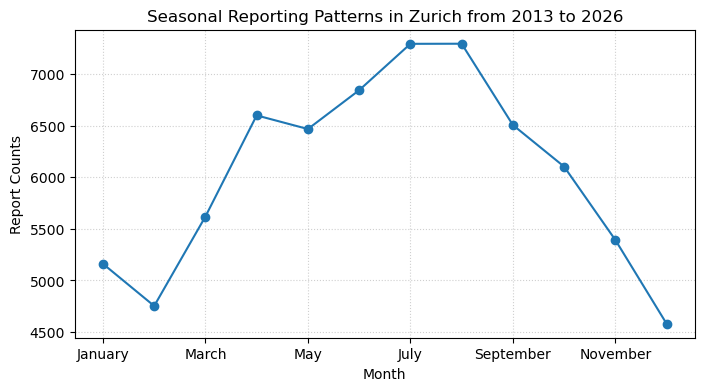

In [27]:
# Aggregate reports by month across all years to identify recurring seasonal patterns
seasonal_counts = (zwn_quartiere_joined.groupby("month_name_requested").size().reset_index(name="seasonal_count"))

# Visualize seasonal variation in reporting activity throughout the year
ax = seasonal_counts.plot(
    kind="line", 
    figsize= (8,4), 
    title="Seasonal Reporting Patterns in Zurich from 2013 to 2026", 
    x="month_name_requested", 
    y="seasonal_count", 
    marker="o", 
    legend=False
)
ax.set_xlabel("Month")
ax.set_ylabel("Report Counts")
ax.grid(True, linestyle=":", alpha=0.6)

plt.savefig("../outputs/report_counts_Zurich_monthly_line.png", dpi=300, bbox_inches="tight")

plt.show()